/tmp/ipykernel_476927/2105210288.py:148: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  dataset = torch.load('/home/lizihao/Work/enzyme_prediction/src/simple2/data/processed/

Feature importances: {'atom': 0.0049820744521101735, 'residue': 0.011763293947731642, 'is_ligand': 0.01575109679779073, 'min_dist': 0.0024261435029996007, 'elec': 0.0019929597239191615, 'props': 0.0017340849189390868, 'temperature': 0.260958025826481}


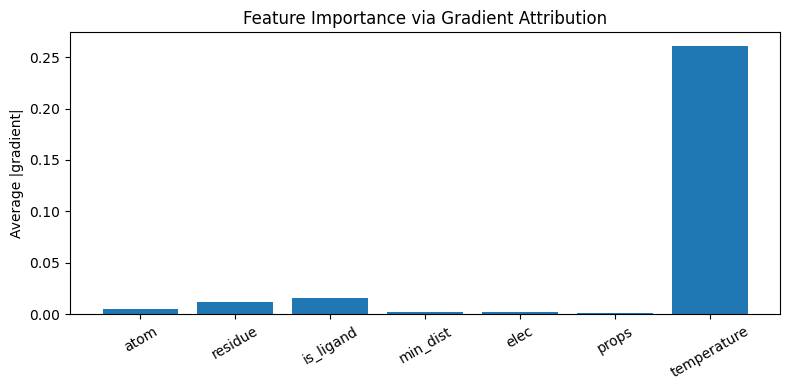

In [4]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import DataLoader
from torch_geometric.nn import radius_graph, global_mean_pool, GATConv
import numpy as np
import matplotlib.pyplot as plt
element_list = ['C', 'N', 'O', 'S', 'P', 'F', 'Cl', 'Br', 'I', 'H']
residue_list = ['ALA','ARG','ASN','ASP','CYS','GLN','GLU','GLY','HIS','ILE',
                'LEU','LYS','MET','PHE','PRO','SER','THR','TRP','TYR','VAL','LIG']
# —— 模型定义（同前） —— 
class PocketGNNWithAttention(nn.Module):
    def __init__(self, node_input_dim, edge_input_dim, hidden_dim=256, num_layers=6, heads=8, dropout=0.1, concat_heads=True):
        super().__init__()
        self.node_encoder = nn.Linear(node_input_dim, hidden_dim)
        self.att_layers = nn.ModuleList()
        cur_dim = hidden_dim
        for i in range(num_layers):
            is_last = (i == num_layers - 1)
            if concat_heads and not is_last:
                self.att_layers.append(
                    GATConv(cur_dim, hidden_dim // heads, heads=heads, dropout=dropout,
                            concat=True, edge_dim=edge_input_dim if i==0 else None)
                )
                cur_dim = hidden_dim
            else:
                self.att_layers.append(
                    GATConv(cur_dim, hidden_dim, heads=heads, dropout=dropout,
                            concat=False, edge_dim=edge_input_dim if i==0 else None)
                )
                cur_dim = hidden_dim

        self.readout = global_mean_pool
        self.temp_mlp = nn.Sequential(nn.Linear(1, hidden_dim), nn.Sigmoid())
        self.mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 2)
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch = data.x, data.edge_index, data.edge_attr, data.batch
        # 打开 x 和 temperature 的梯度追踪
        x.requires_grad_(True)
        data.temperature.requires_grad_(True)

        h = F.relu(self.node_encoder(x))
        for i, layer in enumerate(self.att_layers):
            if hasattr(layer, 'edge_dim') and layer.edge_dim and i==0:
                h_new, att = layer(h, edge_index, edge_attr=edge_attr, return_attention_weights=True)
            else:
                h_new, att = layer(h, edge_index, return_attention_weights=True)
            h = F.elu(h_new)
        g = self.readout(h, batch)  # [B, H]
        temp = data.temperature.view(-1,1)
        temp_embed = self.temp_mlp(temp)
        g = g + temp_embed
        out = self.mlp(g)  # [B,2]
        return out

    def get_embedding(self, data):
        # 同 forward, 但不需 grad
        with torch.no_grad():
            x, edge_index, edge_attr, batch = data.x, data.edge_index, data.edge_attr, data.batch
            h = F.relu(self.node_encoder(x))
            for i, layer in enumerate(self.att_layers):
                if hasattr(layer, 'edge_dim') and layer.edge_dim and i==0:
                    h, _ = layer(h, edge_index, edge_attr=edge_attr, return_attention_weights=True)
                else:
                    h, _ = layer(h, edge_index, return_attention_weights=True)
                h = F.elu(h)
            g = self.readout(h, batch)
            temp = data.temperature.view(-1,1)
            g = g + self.temp_mlp(temp)
        return g

# —— 解释器 —— 
def feature_importance(model, data_loader, device):
    """
    对 loader 中的每一个 batch，计算梯度 -> 特征重要性。
    返回：dict {'atom': val, 'residue': val, 'is_ligand':..., 'min_dist':..., 'elec':..., 'props':..., 'temperature':...}
    """
    model.eval()
    # 各段维度（对应于 graph_builder.py 中的拼接顺序）
    dims = {
        'atom':  len(element_list),
        'residue': len(residue_list),
        'is_ligand': 1,
        'min_dist': 1,
        'elec': 16,
        'props': 3
    }
    cum = {k: 0.0 for k in ['atom','residue','is_ligand','min_dist','elec','props','temperature']}
    count = 0

    for data in data_loader:
        data = data.to(device)
        out = model(data)  # [B,2]
        # 我们对 sum(kcat+Km) 求梯度
        loss = out.sum()
        loss.backward()

        # x.grad: [sum_nodes,B] gradient wrt each node-feature
        x_grad = data.x.grad.abs()  # [N_total, F]
        # temperature.grad: [B]
        t_grad = data.temperature.grad.abs().cpu().numpy()  # [B]

        # 按节点汇总后平均到图：先把 x_grad 按 batch index sum 然后 / num_graphs
        grads_per_graph = global_mean_pool(x_grad, data.batch)  # [B, F]
        grads_per_graph = grads_per_graph.detach().cpu().numpy()

        # 对每个分组计算 mean importance
        idx = 0
        for k, d in dims.items():
            cum[k] += grads_per_graph[:, idx:idx+d].mean()
            idx += d
        cum['temperature'] += t_grad.mean()

        count += 1
        # 清零梯度
        model.zero_grad()
        data.x.grad.zero_()
        data.temperature.grad.zero_()

    # 平均
    for k in cum:
        cum[k] /= count
    return cum

# —— 可视化 —— 
def plot_importance(imp_dict):
    labels = list(imp_dict.keys())
    values = [imp_dict[k] for k in labels]
    plt.figure(figsize=(8,4))
    plt.bar(labels, values)
    plt.ylabel("Average |gradient|")
    plt.title("Feature Importance via Gradient Attribution")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

# —— 主流程示例 —— 
if __name__ == '__main__':
    from torch_geometric.loader import DataLoader
    # 请确保 dataset 已经用之前的 graph_builder.py 生成并保存
    dataset = torch.load('/home/lizihao/Work/enzyme_prediction/src/simple2/data/processed/dataset_NAN_nopqr_rbf.pt')
    loader  = DataLoader(dataset, batch_size=8, shuffle=False)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # 构建模型
    sample = dataset[0]
    node_dim = sample.x.shape[1]
    edge_dim = sample.edge_attr.shape[1]
    model = PocketGNNWithAttention(node_dim, edge_dim).to(device)

    # 加载你训练好的权重
    model.load_state_dict(torch.load('/home/lizihao/Work/enzyme_prediction/src/simple2/outputs/nopqr_attention_rbf/best_model.pt'))

    # 计算重要性
    imp = feature_importance(model, loader, device)
    print("Feature importances:", imp)

    # 可视化
    plot_importance(imp)
